In [15]:
PROJECT_ID = "geo-researh-ai"
LOCATION = "us-central1"

import vertexai
vertexai.init(project=PROJECT_ID, location=LOCATION)

In [16]:
from typing import Dict , TypedDict
from langgraph.graph import StateGraph

In [ ]:
#AgentState --> 1

class AgentState(TypedDict): # Our state Schema
    message : str

def greeting_node(state : AgentState) -> AgentState:
    """ Simple node that gives out a compliment message to the  state. """

    state['message'] = "Hiya " + state["message"] + ", your such a daring stud!"

    return state

In [18]:
graph = StateGraph(AgentState)

graph.add_node("copmenter", greeting_node)

graph.set_entry_point("copmenter")
graph.set_finish_point("copmenter")

app = graph.compile()

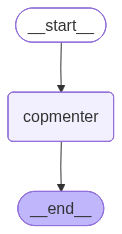

In [19]:
from IPython.display import Image , display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
result = app.invoke({"message":"Bob"})

In [21]:
result["message"]

'Hiya Bob, your such a daring stud!'